# Comparison Notebook for `calculate.py` Outputs

Notebook ini membandingkan dua CSV hasil evaluasi `calculate.py` menggunakan hanya snapshot saat load test benar-benar aktif, yaitu ketika `node1_requests + node2_requests > 0`.

Revisi penting pada versi ini:
- Metrik CPU dan response time dicetak pada tabel, bukan ditaruh sebagai kotak teks di atas grafik.
- Sumbu waktu grafik diselaraskan ke durasi skenario Locust dari folder `tests/locust`, agar Base dan Optimized dibandingkan secara adil.
- Distribusi beban request ditampilkan dalam format time series.

Contoh eksekusi dari terminal:
```bash
BASE_CSV=logs/normal1.csv OPTIMIZED_CSV=logs/opt5.csv RUN_LABEL=normal SCENARIO_NAME=normal OUTPUT_DIR=tests/colab/output jupyter nbconvert --to notebook --execute tests/colab/compare_calculate_outputs.ipynb --output compare_calculate_outputs.executed.ipynb
```


In [ ]:
import os
from pathlib import Path


def detect_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / "logs").exists() and (candidate / "load-balancer").exists():
            return candidate
    return cwd


def first_existing_path(candidates, project_root):
    for candidate in candidates:
        path = project_root / candidate
        if path.exists():
            return path
    return project_root / candidates[0]


def resolve_input_path(raw_value, project_root):
    raw_path = Path(raw_value)
    candidate_paths = []

    if raw_path.is_absolute():
        candidate_paths.append(raw_path)
    else:
        candidate_paths.extend([
            raw_path,
            project_root / raw_path,
            project_root / "logs" / raw_path.name,
            project_root / "tests" / "locust" / "results" / raw_path.name,
        ])

    for candidate in candidate_paths:
        if candidate.exists():
            return candidate.resolve()

    if len(candidate_paths) > 1:
        return candidate_paths[1].resolve()
    return candidate_paths[0].resolve()


PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT", str(detect_project_root()))).resolve()

DEFAULT_BASE_CSV = first_existing_path(
    ["logs/test_base_normal.csv"],
    PROJECT_ROOT,
)
DEFAULT_OPTIMIZED_CSV = first_existing_path(
    ["logs/test_opt2_spike.csv"],
    PROJECT_ROOT,
)

BASE_CSV = resolve_input_path(os.getenv("BASE_CSV", str(DEFAULT_BASE_CSV)), PROJECT_ROOT)
OPTIMIZED_CSV = resolve_input_path(os.getenv("OPTIMIZED_CSV", str(DEFAULT_OPTIMIZED_CSV)), PROJECT_ROOT)
RUN_LABEL = os.getenv("RUN_LABEL", "normal")
SCENARIO_NAME = os.getenv("SCENARIO_NAME", RUN_LABEL).strip().lower()
MOVING_AVG_WINDOW = max(1, int(os.getenv("MOVING_AVG_WINDOW", "5")))
OUTPUT_DIR_RAW = Path(os.getenv("OUTPUT_DIR", "tests/colab/output_spike"))
OUTPUT_DIR = OUTPUT_DIR_RAW if OUTPUT_DIR_RAW.is_absolute() else (PROJECT_ROOT / OUTPUT_DIR_RAW)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root   : {}".format(PROJECT_ROOT))
print("Base CSV       : {}".format(BASE_CSV))
print("Optimized CSV  : {}".format(OPTIMIZED_CSV))
print("Run label      : {}".format(RUN_LABEL))
print("Scenario name  : {}".format(SCENARIO_NAME))
print("Output folder  : {}".format(OUTPUT_DIR.resolve()))
print("Moving average : {}".format(MOVING_AVG_WINDOW))


Project root   : /home/asus/code/loadBalancer/project-fpso
Base CSV       : /home/asus/code/loadBalancer/project-fpso/logs/test_base_spike.csv
Optimized CSV  : /home/asus/code/loadBalancer/project-fpso/logs/test_opt2_spike.csv
Run label      : normal
Scenario name  : normal
Output folder  : /home/asus/code/loadBalancer/project-fpso/tests/colab/output_spike
Moving average : 5


In [34]:
import ast
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

try:
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns
except ImportError:
    raise ImportError(
        "Notebook ini membutuhkan pandas, matplotlib, dan seaborn. "
        "Silakan install paket tersebut pada kernel Jupyter yang Anda gunakan."
    )

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
        "figure.titlesize": 14,
    },
)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

NORMALIZED_CPU_CAPACITY = 100.0
CPU_COLORS = sns.color_palette("colorblind", 2)
DATASET_PALETTE = {
    "Base": CPU_COLORS[0],
    "Optimized": CPU_COLORS[1],
}
NODE_PALETTE = {
    "Node 1": CPU_COLORS[0],
    "Node 2": CPU_COLORS[1],
}

TIME_AXIS_PAD_RATIO = 0.035
TIME_AXIS_MIN_PAD_SECONDS = 2.0

REQUIRED_COLUMNS = [
    "timestamp_utc",
    "node1_cpu_normalized_usage",
    "node2_cpu_normalized_usage",
    "node1_queue",
    "node2_queue",
    "node1_response_ms",
    "node2_response_ms",
    "node1_requests",
    "node2_requests",
]


def weighted_quantile(values, weights, quantile):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)

    values = values[valid]
    weights = weights[valid]
    if values.size == 0:
        return np.nan

    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]

    cumulative = np.cumsum(weights)
    threshold = float(quantile) * cumulative[-1]
    index = np.searchsorted(cumulative, threshold, side="left")
    index = min(index, len(values) - 1)
    return float(values[index])


def compute_weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)

    values = values[valid]
    weights = weights[valid]
    if values.size == 0:
        return np.nan

    return float(np.average(values, weights=weights))


def safe_peak_index(series):
    values = np.asarray(series, dtype=float)
    if values.size == 0 or np.all(~np.isfinite(values)):
        return None
    return int(np.nanargmax(values))


def place_legend_outside(ax):
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=True)


def annotate_peak_left(ax, max_time, max_val, text_label, marker_color):
    if max_time is None or max_val is None:
        return
    if not np.isfinite(max_time) or not np.isfinite(max_val):
        return

    ax.plot(max_time, max_val, marker="o", color=marker_color, markersize=8, zorder=5)
    ax.annotate(
        text_label,
        xy=(max_time, max_val),
        xytext=(0, 25),
        textcoords="offset points",
        ha="center",
        va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
        arrowprops=dict(arrowstyle="->", color="gray", shrinkA=0, shrinkB=5),
        zorder=10,
    )


def apply_axis_layout_padding(ax, apply_y_headroom=True):
    if not getattr(ax, "_x_padding_applied", False):
        ax.set_xlim(right=ax.get_xlim()[1] * 1.05)
        for shared_ax in ax.get_shared_x_axes().get_siblings(ax):
            setattr(shared_ax, "_x_padding_applied", True)

    if apply_y_headroom and not getattr(ax, "_y_headroom_applied", False):
        ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
        for shared_ax in ax.get_shared_y_axes().get_siblings(ax):
            setattr(shared_ax, "_y_headroom_applied", True)


def safe_eval_numeric_ast(node):
    if isinstance(node, ast.Num):
        return float(node.n)

    if hasattr(ast, "Constant") and isinstance(node, ast.Constant):
        if isinstance(node.value, (int, float)):
            return float(node.value)

    if isinstance(node, ast.UnaryOp):
        operand = safe_eval_numeric_ast(node.operand)
        if isinstance(node.op, ast.UAdd):
            return operand
        if isinstance(node.op, ast.USub):
            return -operand

    if isinstance(node, ast.BinOp):
        left = safe_eval_numeric_ast(node.left)
        right = safe_eval_numeric_ast(node.right)

        if isinstance(node.op, ast.Add):
            return left + right
        if isinstance(node.op, ast.Sub):
            return left - right
        if isinstance(node.op, ast.Mult):
            return left * right
        if isinstance(node.op, ast.Div):
            return left / right
        if isinstance(node.op, ast.FloorDiv):
            return left // right

    raise ValueError("Ekspresi numerik tidak didukung saat membaca durasi Locust.")


def read_class_string_value(assign_node):
    value = assign_node.value
    if isinstance(value, ast.Str):
        return value.s
    if hasattr(ast, "Constant") and isinstance(value, ast.Constant) and isinstance(value.value, str):
        return value.value
    return None


def load_locust_scenario_durations(project_root):
    locustfile_path = Path(project_root) / "tests" / "locust" / "locustfile.py"
    if not locustfile_path.exists():
        return {}

    tree = ast.parse(locustfile_path.read_text())
    durations = {}

    for node in tree.body:
        if not isinstance(node, ast.ClassDef):
            continue

        scenario_name = None
        duration_sec = None

        for statement in node.body:
            if not isinstance(statement, ast.Assign):
                continue

            target_names = [target.id for target in statement.targets if isinstance(target, ast.Name)]
            if "name" in target_names:
                scenario_name = read_class_string_value(statement)

            if "duration_sec" in target_names:
                try:
                    duration_sec = float(safe_eval_numeric_ast(statement.value))
                except Exception:
                    duration_sec = None

        if scenario_name and duration_sec is not None:
            durations[str(scenario_name).strip().lower()] = duration_sec

    return durations


def infer_window_seconds(df):
    if "window_ms" in df.columns:
        window_ms = pd.to_numeric(df["window_ms"], errors="coerce").dropna()
        window_ms = window_ms[window_ms > 0]
        if not window_ms.empty:
            return float(window_ms.mode().iloc[0]) / 1000.0

    if len(df) >= 2:
        diffs = df["timestamp_utc"].diff().dt.total_seconds().dropna()
        diffs = diffs[diffs > 0]
        if not diffs.empty:
            return float(diffs.median())

    return 1.0


def attach_scenario_time_axis(df, scenario_duration_seconds=None):
    df = df.copy()
    df["plot_seconds"] = df["observed_elapsed_seconds"]

    if scenario_duration_seconds is not None and len(df) >= 2:
        df["plot_seconds"] = np.linspace(0.0, float(scenario_duration_seconds), len(df))
    elif scenario_duration_seconds is not None and len(df) == 1:
        df["plot_seconds"] = np.array([float(scenario_duration_seconds)])

    return df


def format_time_axis(ax, time_limit_seconds, x_label):
    if time_limit_seconds is not None:
        time_limit_seconds = float(time_limit_seconds)
        pad_seconds = max(time_limit_seconds * TIME_AXIS_PAD_RATIO, TIME_AXIS_MIN_PAD_SECONDS)
        ax.set_xlim(-pad_seconds, time_limit_seconds + pad_seconds)
        ax.set_xticks(np.linspace(0.0, time_limit_seconds, 5))
    else:
        ax.margins(x=0.04)
    ax.set_xlabel(x_label)
    ax.tick_params(axis="x", labelbottom=True)


def load_evaluation_csv(path, dataset_label, moving_avg_window=5):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError("File untuk {} tidak ditemukan: {}".format(dataset_label, path))

    raw_df = pd.read_csv(path, skipinitialspace=True)
    if raw_df.empty:
        raise ValueError("Dataset {} kosong: {}".format(dataset_label, path))

    missing_columns = [column for column in REQUIRED_COLUMNS if column not in raw_df.columns]
    if missing_columns:
        raise ValueError(
            "Dataset {} tidak memiliki kolom wajib: {}".format(
                dataset_label,
                ", ".join(missing_columns),
            )
        )

    raw_df = raw_df.copy()
    raw_df["timestamp_utc"] = pd.to_datetime(raw_df["timestamp_utc"], errors="coerce", utc=True)

    numeric_columns = [column for column in REQUIRED_COLUMNS if column != "timestamp_utc"]
    for column in numeric_columns:
        raw_df[column] = pd.to_numeric(raw_df[column], errors="coerce")

    raw_df = raw_df.dropna(subset=["timestamp_utc"]).sort_values("timestamp_utc").reset_index(drop=True)
    if raw_df.empty:
        raise ValueError("Semua timestamp invalid pada dataset {}: {}".format(dataset_label, path))

    for column in [
        "node1_requests",
        "node2_requests",
        "node1_queue",
        "node2_queue",
        "node1_cpu_normalized_usage",
        "node2_cpu_normalized_usage",
    ]:
        raw_df[column] = raw_df[column].fillna(0).clip(lower=0)

    for column in ["node1_response_ms", "node2_response_ms"]:
        raw_df[column] = raw_df[column].where(raw_df[column] > 0)

    raw_df["total_requests"] = raw_df["node1_requests"] + raw_df["node2_requests"]
    active_df = raw_df.loc[raw_df["total_requests"] > 0].copy().reset_index(drop=True)
    if active_df.empty:
        raise ValueError(
            "Dataset {} tidak memiliki snapshot aktif dengan total request > 0.".format(dataset_label)
        )

    window_seconds = infer_window_seconds(active_df)

    active_df["observed_elapsed_seconds"] = (
        active_df["timestamp_utc"] - active_df["timestamp_utc"].iloc[0]
    ).dt.total_seconds()

    active_df["node1_cpu_ma"] = active_df["node1_cpu_normalized_usage"].rolling(
        window=moving_avg_window,
        min_periods=1,
    ).mean()
    active_df["node2_cpu_ma"] = active_df["node2_cpu_normalized_usage"].rolling(
        window=moving_avg_window,
        min_periods=1,
    ).mean()

    active_df["node1_requests_ma"] = active_df["node1_requests"].rolling(
        window=moving_avg_window,
        min_periods=1,
    ).mean()
    active_df["node2_requests_ma"] = active_df["node2_requests"].rolling(
        window=moving_avg_window,
        min_periods=1,
    ).mean()

    active_df["total_queue"] = active_df["node1_queue"] + active_df["node2_queue"]

    node1_rt_component = active_df["node1_response_ms"].fillna(0) * active_df["node1_requests"]
    node2_rt_component = active_df["node2_response_ms"].fillna(0) * active_df["node2_requests"]
    active_df["weighted_rt_ms"] = (
        node1_rt_component + node2_rt_component
    ) / active_df["total_requests"].replace(0, np.nan)
    active_df.loc[active_df["weighted_rt_ms"] <= 0, "weighted_rt_ms"] = np.nan
    active_df["weighted_rt_ma"] = active_df["weighted_rt_ms"].rolling(
        window=moving_avg_window,
        min_periods=1,
    ).mean()

    active_df["request_gap"] = (active_df["node1_requests"] - active_df["node2_requests"]).abs()
    active_df["dataset"] = dataset_label

    metadata = {
        "Dataset": dataset_label,
        "Source File": str(path),
        "Baris Awal": int(len(raw_df)),
        "Baris Aktif Dipakai": int(len(active_df)),
        "Baris Idle Dibuang": int(len(raw_df) - len(active_df)),
        "Window Snapshot (detik)": float(window_seconds),
        "Total Request": float(active_df["total_requests"].sum()),
        "Span Aktif Terdeteksi (detik)": float(active_df["observed_elapsed_seconds"].iloc[-1]),
    }

    return active_df, metadata


def build_response_time_distribution(df, dataset_label):
    parts = []
    for node_name, request_col, rt_col in [
        ("Node 1", "node1_requests", "node1_response_ms"),
        ("Node 2", "node2_requests", "node2_response_ms"),
    ]:
        node_df = df[["timestamp_utc", "observed_elapsed_seconds", "plot_seconds", request_col, rt_col]].copy()
        node_df["request_count"] = pd.to_numeric(node_df[request_col], errors="coerce").fillna(0).clip(lower=0)
        node_df["response_time_ms"] = pd.to_numeric(node_df[rt_col], errors="coerce")
        node_df = node_df[
            (node_df["request_count"] > 0)
            & node_df["response_time_ms"].notna()
            & (node_df["response_time_ms"] > 0)
        ].copy()
        node_df["dataset"] = dataset_label
        node_df["node"] = node_name
        parts.append(
            node_df[[
                "dataset",
                "node",
                "timestamp_utc",
                "observed_elapsed_seconds",
                "plot_seconds",
                "response_time_ms",
                "request_count",
            ]]
        )

    rt_long = pd.concat(parts, ignore_index=True)
    if rt_long.empty:
        raise ValueError("Tidak ada response time aktif yang valid untuk dataset {}.".format(dataset_label))
    return rt_long


def compute_cpu_metrics(df, dataset_label):
    cpu1 = df["node1_cpu_normalized_usage"].to_numpy(dtype=float)
    cpu2 = df["node2_cpu_normalized_usage"].to_numpy(dtype=float)

    di_series = np.abs(cpu1 - cpu2) / NORMALIZED_CPU_CAPACITY
    bcu_series = 1.0 - di_series

    macro_di = abs(np.mean(cpu1) - np.mean(cpu2)) / NORMALIZED_CPU_CAPACITY
    macro_bcu = 1.0 - macro_di

    return {
        "Dataset": dataset_label,
        "Rata-rata CPU Node 1 (%)": float(np.mean(cpu1)),
        "Rata-rata CPU Node 2 (%)": float(np.mean(cpu2)),
        "Puncak CPU Node 1 (%)": float(np.max(cpu1)),
        "Puncak CPU Node 2 (%)": float(np.max(cpu2)),
        "DI Mikro": float(np.mean(di_series)),
        "DI Makro": float(macro_di),
        "BCU Mikro": float(np.mean(bcu_series)),
        "BCU Makro": float(macro_bcu),
    }


def compute_rt_metrics(df, rt_distribution_df, dataset_label):
    subset = rt_distribution_df.loc[rt_distribution_df["dataset"] == dataset_label].copy()
    values = subset["response_time_ms"].to_numpy(dtype=float)
    weights = subset["request_count"].to_numpy(dtype=float)

    max_idx = int(subset["response_time_ms"].idxmax())
    peak_snapshot_idx = int(df["weighted_rt_ms"].idxmax()) if df["weighted_rt_ms"].notna().any() else None

    peak_snapshot_rt = np.nan
    peak_snapshot_time = np.nan
    if peak_snapshot_idx is not None:
        peak_snapshot_rt = float(df.loc[peak_snapshot_idx, "weighted_rt_ms"])
        peak_snapshot_time = float(df.loc[peak_snapshot_idx, "plot_seconds"])

    return {
        "Dataset": dataset_label,
        "Mean RT (ms)": compute_weighted_mean(values, weights),
        "P50 RT (ms)": weighted_quantile(values, weights, 0.50),
        "P90 RT (ms)": weighted_quantile(values, weights, 0.90),
        "P95 RT (ms)": weighted_quantile(values, weights, 0.95),
        "P99 RT (ms)": weighted_quantile(values, weights, 0.99),
        "RT Tertinggi (ms)": float(subset["response_time_ms"].max()),
        "Waktu RT Tertinggi (detik)": float(subset.loc[max_idx, "plot_seconds"]),
        "Peak Snapshot RT (ms)": peak_snapshot_rt,
        "Waktu Peak Snapshot RT (detik)": peak_snapshot_time,
    }


def compute_queue_metrics(df, dataset_label):
    queue_values = df["total_queue"].to_numpy(dtype=float)
    peak_idx = safe_peak_index(queue_values)

    peak_time = np.nan
    if peak_idx is not None:
        peak_time = float(df["plot_seconds"].iloc[peak_idx])

    return {
        "Dataset": dataset_label,
        "Rata-rata Queue": float(np.mean(queue_values)),
        "P95 Queue": float(np.percentile(queue_values, 95)),
        "Puncak Queue": float(np.max(queue_values)),
        "Waktu Puncak Queue (detik)": peak_time,
    }


def compute_load_distribution_metrics(df, dataset_label):
    node1_total = float(df["node1_requests"].sum())
    node2_total = float(df["node2_requests"].sum())
    total_requests = float(node1_total + node2_total)

    if total_requests <= 0:
        share_node1 = np.nan
        share_node2 = np.nan
        gap_pct = np.nan
    else:
        share_node1 = 100.0 * node1_total / total_requests
        share_node2 = 100.0 * node2_total / total_requests
        gap_pct = 100.0 * abs(node1_total - node2_total) / total_requests

    gap_values = df["request_gap"].to_numpy(dtype=float)
    gap_idx = safe_peak_index(gap_values)
    gap_time = np.nan
    gap_max = np.nan
    if gap_idx is not None:
        gap_time = float(df["plot_seconds"].iloc[gap_idx])
        gap_max = float(gap_values[gap_idx])

    return {
        "Dataset": dataset_label,
        "Request Node 1": node1_total,
        "Request Node 2": node2_total,
        "Total Request": total_requests,
        "Share Node 1 (%)": share_node1,
        "Share Node 2 (%)": share_node2,
        "Gap Distribusi (%)": gap_pct,
        "Gap Maks Snapshot (request)": gap_max,
        "Waktu Gap Maks (detik)": gap_time,
    }


def build_weighted_ecdf(rt_df, dataset_label):
    subset = rt_df.loc[rt_df["dataset"] == dataset_label, ["response_time_ms", "request_count"]].copy()
    grouped = subset.groupby("response_time_ms", as_index=False)["request_count"].sum().sort_values("response_time_ms")

    values = grouped["response_time_ms"].to_numpy(dtype=float)
    weights = grouped["request_count"].to_numpy(dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)

    values = values[valid]
    weights = weights[valid]
    if values.size == 0:
        raise ValueError("Distribusi response time kosong untuk dataset {}.".format(dataset_label))

    cumulative = np.cumsum(weights) / np.sum(weights)
    return values, cumulative


def plot_cpu_panel(ax, df, title, moving_avg_window, time_limit_seconds, x_label):
    x_values = df["plot_seconds"].to_numpy(dtype=float)
    cpu1 = df["node1_cpu_normalized_usage"].to_numpy(dtype=float)
    cpu2 = df["node2_cpu_normalized_usage"].to_numpy(dtype=float)
    cpu1_ma = df["node1_cpu_ma"].to_numpy(dtype=float)
    cpu2_ma = df["node2_cpu_ma"].to_numpy(dtype=float)

    ax.plot(x_values, cpu1, color=CPU_COLORS[0], alpha=0.30, linewidth=1.1, label="Node 1 Raw")
    ax.plot(x_values, cpu1_ma, color=CPU_COLORS[0], linewidth=2.6, label="Node 1 MA({})".format(moving_avg_window))
    ax.plot(x_values, cpu2, color=CPU_COLORS[1], alpha=0.30, linewidth=1.1, label="Node 2 Raw")
    ax.plot(x_values, cpu2_ma, color=CPU_COLORS[1], linewidth=2.6, label="Node 2 MA({})".format(moving_avg_window))

    peak1_idx = safe_peak_index(cpu1)
    peak2_idx = safe_peak_index(cpu2)
    if peak1_idx is not None:
        annotate_peak_left(
            ax,
            float(x_values[peak1_idx]),
            float(cpu1[peak1_idx]),
            "N1: {:.1f}%".format(float(cpu1[peak1_idx])),
            CPU_COLORS[0],
        )
    if peak2_idx is not None:
        annotate_peak_left(
            ax,
            float(x_values[peak2_idx]),
            float(cpu2[peak2_idx]),
            "N2: {:.1f}%".format(float(cpu2[peak2_idx])),
            CPU_COLORS[1],
        )

    ax.set_title(title)
    format_time_axis(ax, time_limit_seconds, x_label)
    ax.set_ylabel("CPU Ternormalisasi (%)")
    apply_axis_layout_padding(ax, apply_y_headroom=True)

def plot_response_time_panel(ax, df, title, moving_avg_window, time_limit_seconds, x_label):
    node_series = [
        ("Node 1", "node1_requests", "node1_response_ms", NODE_PALETTE["Node 1"], "N1"),
        ("Node 2", "node2_requests", "node2_response_ms", NODE_PALETTE["Node 2"], "N2"),
    ]

    plotted = False
    for node_label, request_col, rt_col, color, rt_short in node_series:
        valid = (df[request_col] > 0) & df[rt_col].notna()
        if not valid.any():
            continue

        x_values = df.loc[valid, "plot_seconds"].to_numpy(dtype=float)
        rt_raw = df.loc[valid, rt_col].to_numpy(dtype=float)
        rt_ma = pd.Series(rt_raw).rolling(window=moving_avg_window, min_periods=1).mean().to_numpy(dtype=float)

        ax.plot(
            x_values,
            rt_raw,
            color=color,
            alpha=0.25,
            linestyle="--",
            linewidth=1,
            label="{} Raw".format(rt_short),
        )
        ax.plot(
            x_values,
            rt_ma,
            color=color,
            alpha=1.0,
            linewidth=2,
            label="{} MA({})".format(rt_short, moving_avg_window),
        )

        peak_idx = safe_peak_index(rt_raw)
        if peak_idx is not None:
            peak_val = float(rt_raw[peak_idx])
            peak_time = float(x_values[peak_idx])
            annotate_peak_left(
                ax,
                peak_time,
                peak_val,
                "{}: {:.1f} ms".format(rt_short, peak_val),
                color,
            )
        plotted = True

    if not plotted:
        raise ValueError("Tidak ada response time node yang valid untuk diplot.")

    ax.set_title(title)
    format_time_axis(ax, time_limit_seconds, x_label)
    ax.set_ylabel("Response Time per Node (ms)")
    apply_axis_layout_padding(ax, apply_y_headroom=True)

def plot_request_distribution_panel(ax, df, title, moving_avg_window, time_limit_seconds, x_label):
    x_values = df["plot_seconds"].to_numpy(dtype=float)
    node1 = df["node1_requests"].to_numpy(dtype=float)
    node2 = df["node2_requests"].to_numpy(dtype=float)
    node1_ma = df["node1_requests_ma"].to_numpy(dtype=float)
    node2_ma = df["node2_requests_ma"].to_numpy(dtype=float)

    ax.plot(x_values, node1, color=NODE_PALETTE["Node 1"], alpha=0.30, linewidth=1.1, label="Node 1 Raw")
    ax.plot(x_values, node1_ma, color=NODE_PALETTE["Node 1"], linewidth=2.5, label="Node 1 MA({})".format(moving_avg_window))
    ax.plot(x_values, node2, color=NODE_PALETTE["Node 2"], alpha=0.30, linewidth=1.1, label="Node 2 Raw")
    ax.plot(x_values, node2_ma, color=NODE_PALETTE["Node 2"], linewidth=2.5, label="Node 2 MA({})".format(moving_avg_window))

    ax.set_title(title)
    format_time_axis(ax, time_limit_seconds, x_label)
    ax.set_ylabel("Request per Snapshot")


def save_and_show(fig, output_path):
    fig.subplots_adjust(right=0.8)
    plt.savefig(str(output_path), bbox_inches="tight", dpi=300)
    backend_name = str(matplotlib.get_backend()).lower()
    if "agg" not in backend_name:
        plt.show()
    plt.close(fig)
    print("Tersimpan: {}".format(Path(output_path).resolve()))


In [35]:
locust_durations = load_locust_scenario_durations(PROJECT_ROOT)
EXPECTED_SCENARIO_DURATION = locust_durations.get(SCENARIO_NAME)

base_df, base_meta = load_evaluation_csv(BASE_CSV, "Base", MOVING_AVG_WINDOW)
optimized_df, optimized_meta = load_evaluation_csv(OPTIMIZED_CSV, "Optimized", MOVING_AVG_WINDOW)

base_df = attach_scenario_time_axis(base_df, EXPECTED_SCENARIO_DURATION)
optimized_df = attach_scenario_time_axis(optimized_df, EXPECTED_SCENARIO_DURATION)

for meta, df in [(base_meta, base_df), (optimized_meta, optimized_df)]:
    meta["Skenario Locust"] = SCENARIO_NAME
    meta["Durasi Skenario Locust (detik)"] = float(EXPECTED_SCENARIO_DURATION) if EXPECTED_SCENARIO_DURATION is not None else np.nan
    meta["Durasi Grafik / Makespan Analisis (detik)"] = float(df["plot_seconds"].iloc[-1]) if len(df) > 0 else np.nan

TIME_AXIS_LABEL = "Waktu Skenario (detik)" if EXPECTED_SCENARIO_DURATION is not None else "Waktu Aktif Terdeteksi (detik)"
COMMON_TIME_LIMIT_SECONDS = float(EXPECTED_SCENARIO_DURATION) if EXPECTED_SCENARIO_DURATION is not None else max(float(base_df["plot_seconds"].iloc[-1]), float(optimized_df["plot_seconds"].iloc[-1]))

rt_distribution_df = pd.concat(
    [
        build_response_time_distribution(base_df, "Base"),
        build_response_time_distribution(optimized_df, "Optimized"),
    ],
    ignore_index=True,
)

base_cpu_metrics = compute_cpu_metrics(base_df, "Base")
optimized_cpu_metrics = compute_cpu_metrics(optimized_df, "Optimized")
cpu_metrics_df = pd.DataFrame([base_cpu_metrics, optimized_cpu_metrics])

base_rt_metrics = compute_rt_metrics(base_df, rt_distribution_df, "Base")
optimized_rt_metrics = compute_rt_metrics(optimized_df, rt_distribution_df, "Optimized")
rt_metrics_df = pd.DataFrame([base_rt_metrics, optimized_rt_metrics])

base_queue_metrics = compute_queue_metrics(base_df, "Base")
optimized_queue_metrics = compute_queue_metrics(optimized_df, "Optimized")
queue_metrics_df = pd.DataFrame([base_queue_metrics, optimized_queue_metrics])

base_load_metrics = compute_load_distribution_metrics(base_df, "Base")
optimized_load_metrics = compute_load_distribution_metrics(optimized_df, "Optimized")
load_metrics_df = pd.DataFrame([base_load_metrics, optimized_load_metrics])

cleaning_summary_df = pd.DataFrame([base_meta, optimized_meta])
overview_summary_df = pd.DataFrame(
    [
        {
            "Dataset": "Base",
            "Total Request": base_meta["Total Request"],
            "Makespan Analisis (detik)": base_meta["Durasi Grafik / Makespan Analisis (detik)"],
            "Mean RT (ms)": base_rt_metrics["Mean RT (ms)"],
            "P95 RT (ms)": base_rt_metrics["P95 RT (ms)"],
            "RT Tertinggi (ms)": base_rt_metrics["RT Tertinggi (ms)"],
            "DI Mikro": base_cpu_metrics["DI Mikro"],
            "DI Makro": base_cpu_metrics["DI Makro"],
            "Puncak Queue": base_queue_metrics["Puncak Queue"],
            "Gap Distribusi (%)": base_load_metrics["Gap Distribusi (%)"],
        },
        {
            "Dataset": "Optimized",
            "Total Request": optimized_meta["Total Request"],
            "Makespan Analisis (detik)": optimized_meta["Durasi Grafik / Makespan Analisis (detik)"],
            "Mean RT (ms)": optimized_rt_metrics["Mean RT (ms)"],
            "P95 RT (ms)": optimized_rt_metrics["P95 RT (ms)"],
            "RT Tertinggi (ms)": optimized_rt_metrics["RT Tertinggi (ms)"],
            "DI Mikro": optimized_cpu_metrics["DI Mikro"],
            "DI Makro": optimized_cpu_metrics["DI Makro"],
            "Puncak Queue": optimized_queue_metrics["Puncak Queue"],
            "Gap Distribusi (%)": optimized_load_metrics["Gap Distribusi (%)"],
        },
    ]
)

print("Catatan pembersihan: seluruh analisis hanya memakai snapshot dengan total_requests > 0.")
if EXPECTED_SCENARIO_DURATION is not None:
    print(
        "Makespan komparatif pada grafik disamakan dengan skenario Locust '{}' sebesar {} detik dari tests/locust/locustfile.py.".format(
            SCENARIO_NAME,
            int(EXPECTED_SCENARIO_DURATION),
        )
    )
    print("Span aktif timestamp asli tetap ditampilkan pada tabel cleaning hanya sebagai audit perekaman.")
else:
    print("Durasi skenario Locust tidak terdeteksi, sehingga grafik memakai span aktif timestamp asli.")

display(cleaning_summary_df.round(2))
display(overview_summary_df.round(4))


Catatan pembersihan: seluruh analisis hanya memakai snapshot dengan total_requests > 0.
Makespan komparatif pada grafik disamakan dengan skenario Locust 'normal' sebesar 900 detik dari tests/locust/locustfile.py.
Span aktif timestamp asli tetap ditampilkan pada tabel cleaning hanya sebagai audit perekaman.


,Dataset,Source File,Baris Awal,Baris Aktif Dipakai,Baris Idle Dibuang,Window Snapshot (detik),Total Request,Span Aktif Terdeteksi (detik),Skenario Locust,Durasi Skenario Locust (detik),Durasi Grafik / Makespan Analisis (detik)
0,Base,/home/asus/code/loadBalancer/project-fpso/logs...,271,271,0,1.0,10802.0,270.0,normal,900.0,900.0
1,Optimized,/home/asus/code/loadBalancer/project-fpso/logs...,271,271,0,1.0,10820.0,270.0,normal,900.0,900.0


,Dataset,Total Request,Makespan Analisis (detik),Mean RT (ms),P95 RT (ms),RT Tertinggi (ms),DI Mikro,DI Makro,Puncak Queue,Gap Distribusi (%)
0,Base,10802.0,900.0,111.4275,163.2632,246.0323,0.1097,0.0923,17.0,0.4999
1,Optimized,10820.0,900.0,88.5095,125.8000,172.0000,0.1061,0.0633,13.0,13.4566


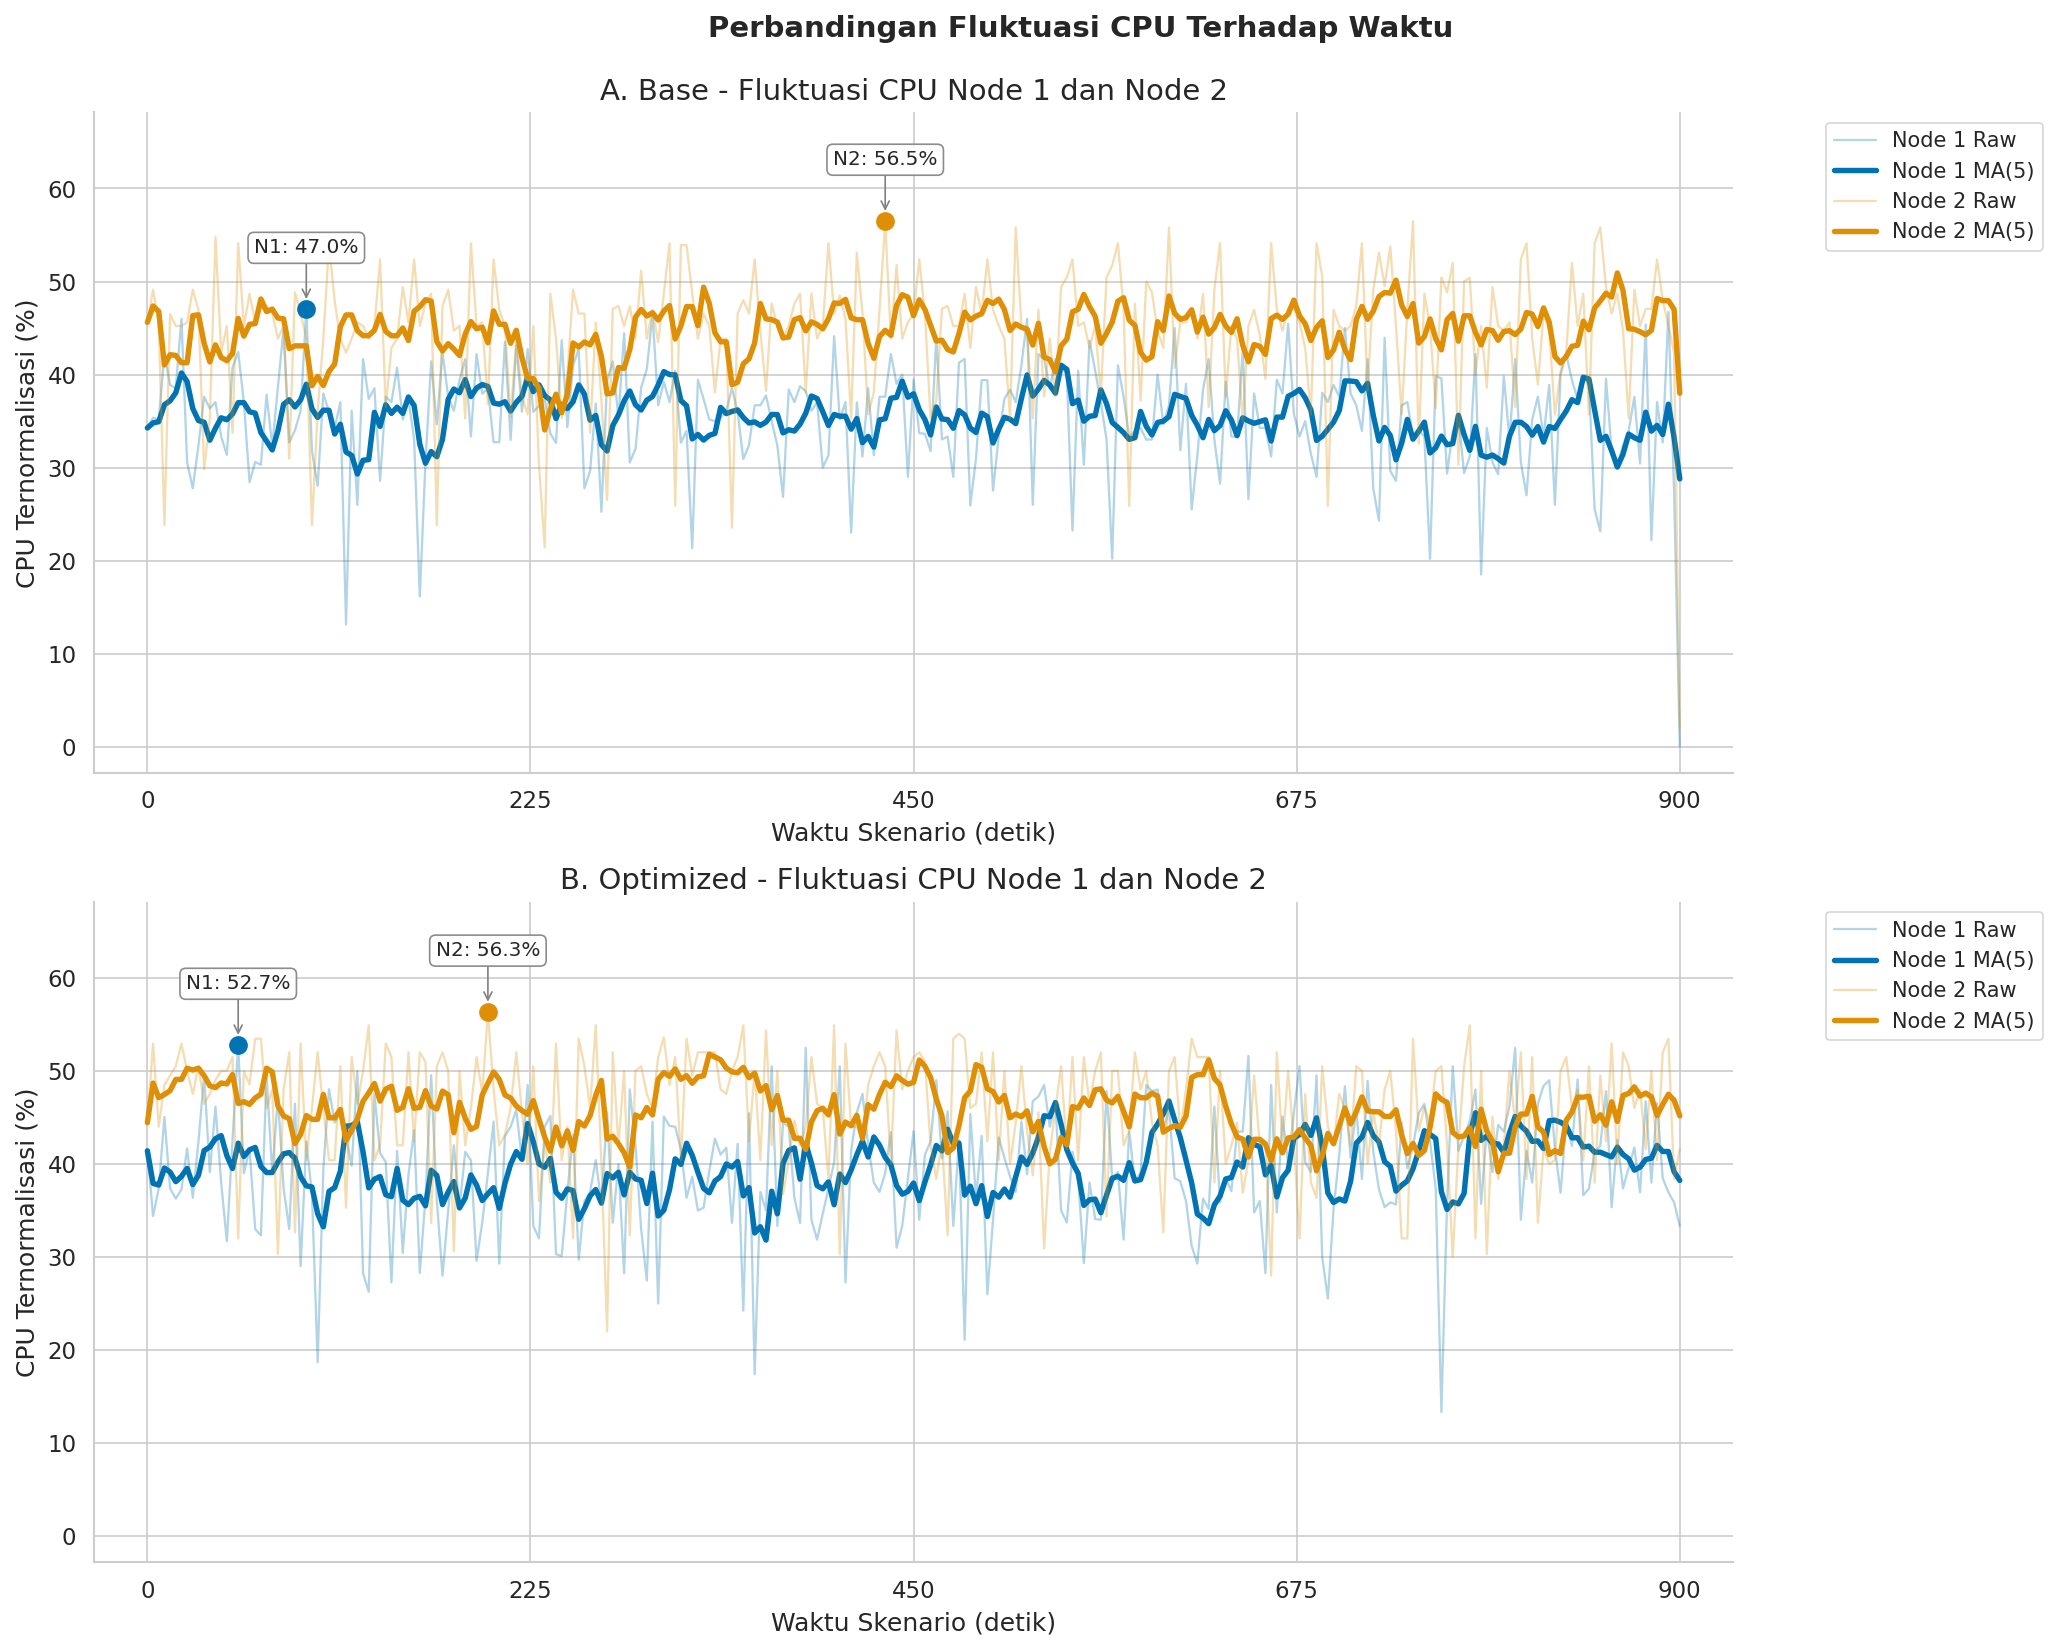

Tersimpan: /home/asus/code/loadBalancer/project-fpso/tests/colab/output_spike/normal_cpu_fluctuation_comparison.png


,Dataset,Rata-rata CPU Node 1 (%),Rata-rata CPU Node 2 (%),Puncak CPU Node 1 (%),Puncak CPU Node 2 (%),DI Mikro,DI Makro,BCU Mikro,BCU Makro
0,Base,35.30,44.53,47.00,56.47,0.1097,0.0923,0.8903,0.9077
1,Optimized,39.46,45.79,52.75,56.31,0.1061,0.0633,0.8939,0.9367


In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14.5, 11), sharex=True, sharey=True)

plot_cpu_panel(
    axes[0],
    base_df,
    "A. Base - Fluktuasi CPU Node 1 dan Node 2",
    MOVING_AVG_WINDOW,
    COMMON_TIME_LIMIT_SECONDS,
    TIME_AXIS_LABEL,
)
plot_cpu_panel(
    axes[1],
    optimized_df,
    "B. Optimized - Fluktuasi CPU Node 1 dan Node 2",
    MOVING_AVG_WINDOW,
    COMMON_TIME_LIMIT_SECONDS,
    TIME_AXIS_LABEL,
)

for ax in axes:
    place_legend_outside(ax)

fig.suptitle("Perbandingan Fluktuasi CPU Terhadap Waktu", y=0.995, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.85, 1])

cpu_plot_path = OUTPUT_DIR / "{}_cpu_fluctuation_comparison.png".format(RUN_LABEL)
save_and_show(fig, cpu_plot_path)

display(
    cpu_metrics_df.round(
        {
            "Rata-rata CPU Node 1 (%)": 2,
            "Rata-rata CPU Node 2 (%)": 2,
            "Puncak CPU Node 1 (%)": 2,
            "Puncak CPU Node 2 (%)": 2,
            "DI Mikro": 4,
            "DI Makro": 4,
            "BCU Mikro": 4,
            "BCU Makro": 4,
        }
    )
)


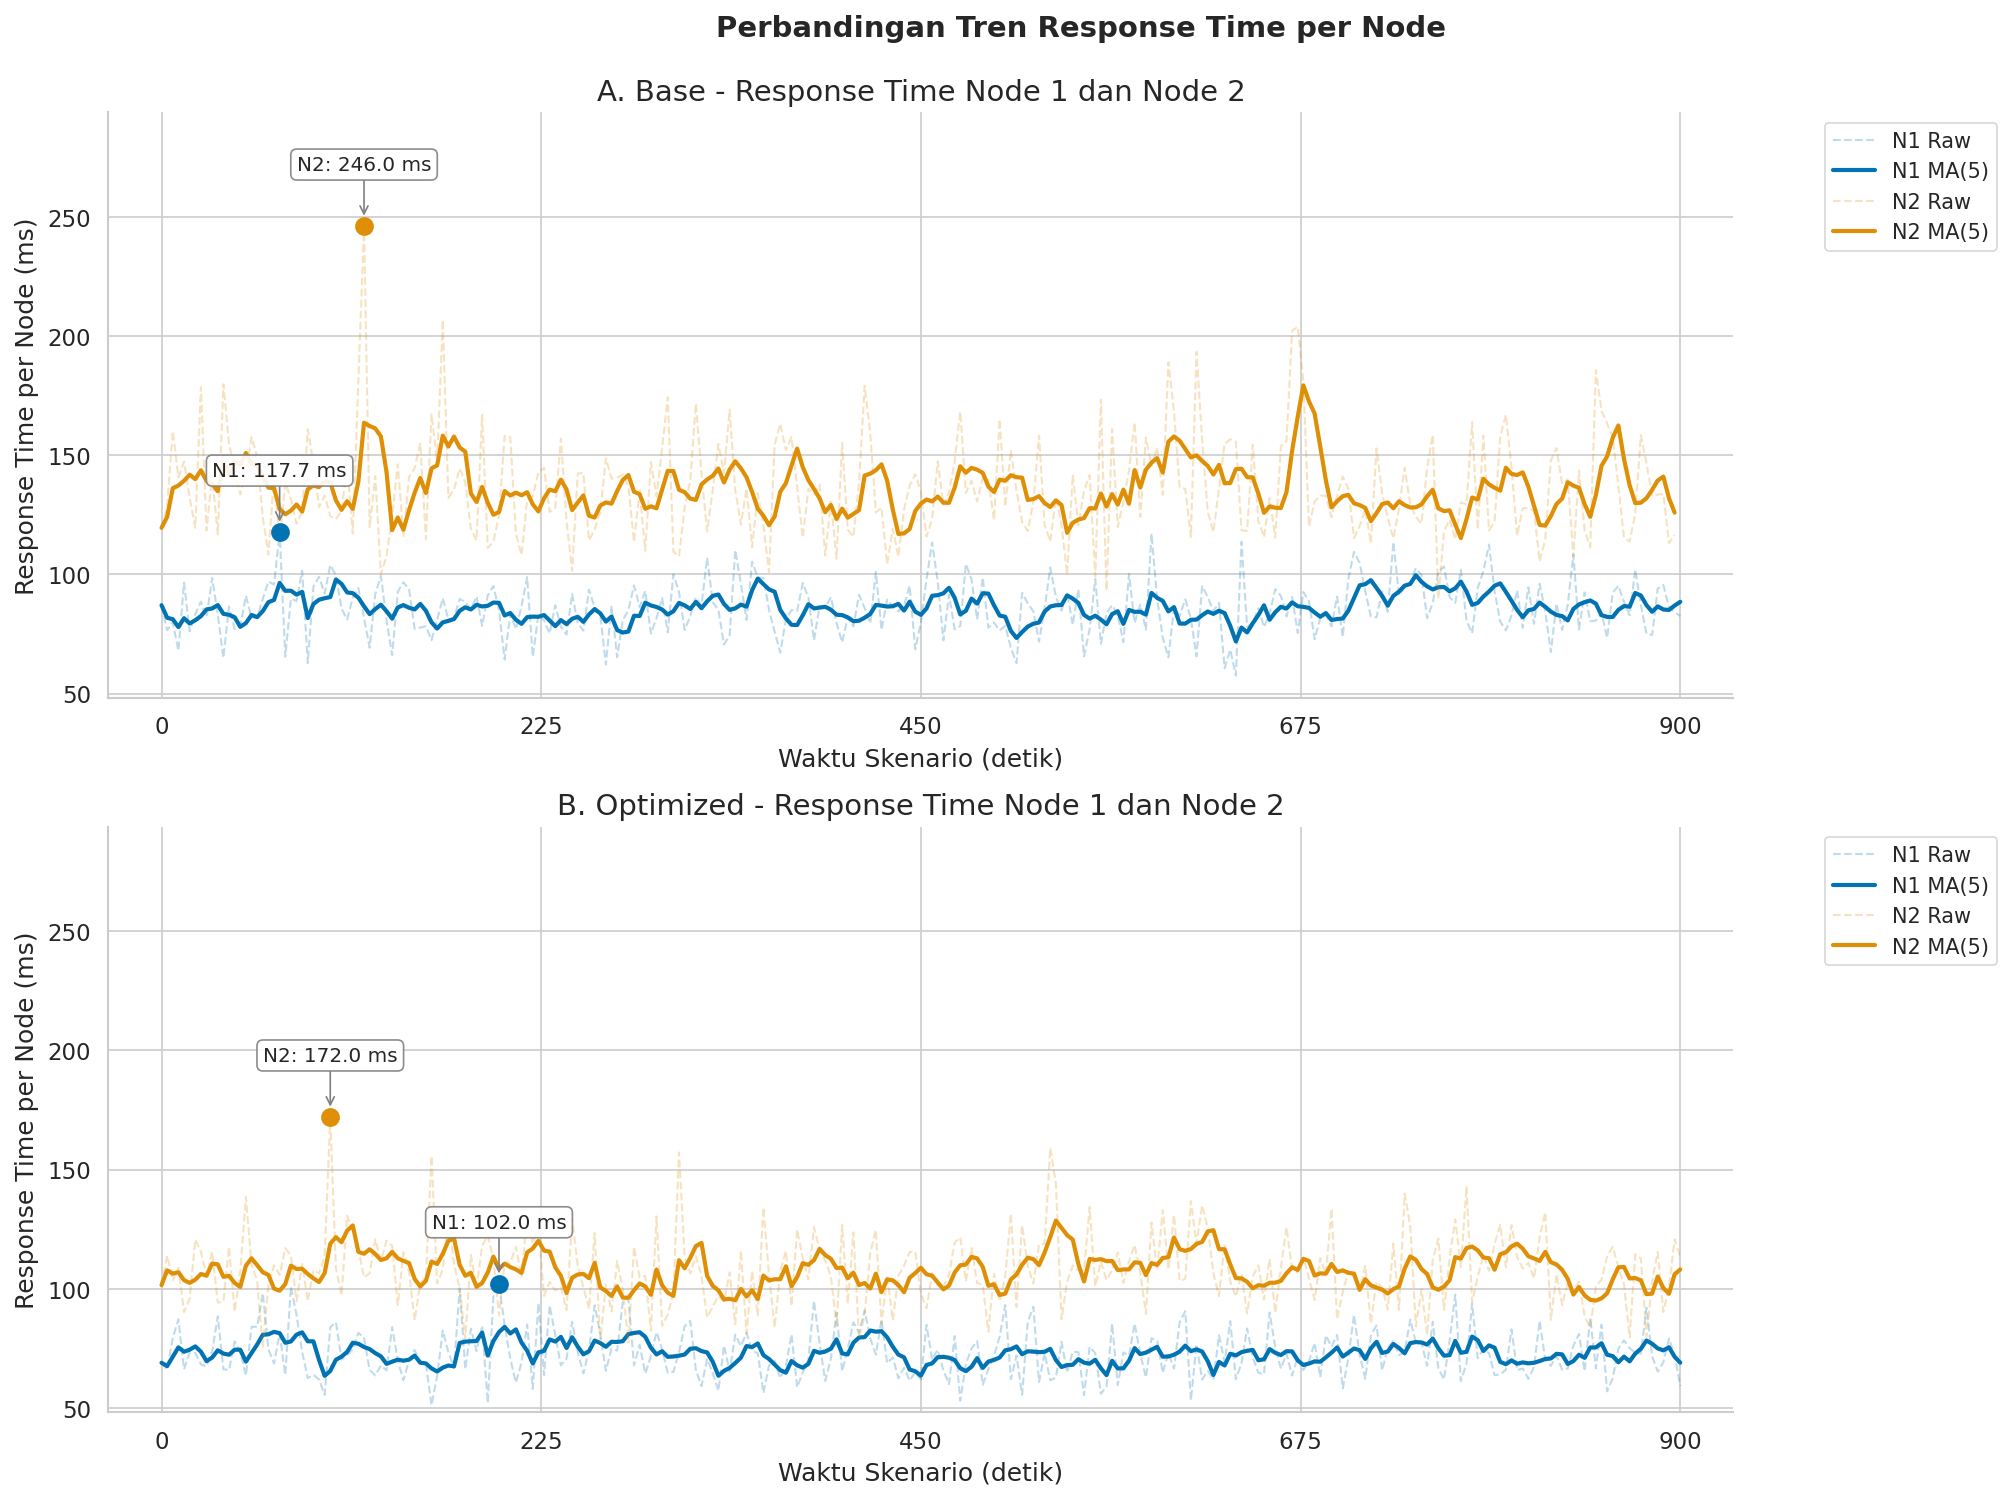

Tersimpan: /home/asus/code/loadBalancer/project-fpso/tests/colab/output_spike/normal_response_time_trend.png


,Dataset,Mean RT (ms),P50 RT (ms),P90 RT (ms),P95 RT (ms),P99 RT (ms),RT Tertinggi (ms),Waktu RT Tertinggi (detik),Peak Snapshot RT (ms),Waktu Peak Snapshot RT (detik)
0,Base,111.43,106.96,154.69,163.26,188.96,246.03,120.0,159.78,120.00
1,Optimized,88.51,84.92,117.16,125.80,142.95,172.00,100.0,120.10,526.67


In [37]:
fig, axes = plt.subplots(2, 1, figsize=(14.5, 10), sharex=True, sharey=True)

plot_response_time_panel(
    axes[0],
    base_df,
    "A. Base - Response Time Node 1 dan Node 2",
    MOVING_AVG_WINDOW,
    COMMON_TIME_LIMIT_SECONDS,
    TIME_AXIS_LABEL,
)
plot_response_time_panel(
    axes[1],
    optimized_df,
    "B. Optimized - Response Time Node 1 dan Node 2",
    MOVING_AVG_WINDOW,
    COMMON_TIME_LIMIT_SECONDS,
    TIME_AXIS_LABEL,
)

for ax in axes:
    place_legend_outside(ax)

fig.suptitle("Perbandingan Tren Response Time per Node", y=0.995, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.85, 1])

rt_trend_plot_path = OUTPUT_DIR / "{}_response_time_trend.png".format(RUN_LABEL)
save_and_show(fig, rt_trend_plot_path)

display(
    rt_metrics_df.round(
        {
            "Mean RT (ms)": 2,
            "P50 RT (ms)": 2,
            "P90 RT (ms)": 2,
            "P95 RT (ms)": 2,
            "P99 RT (ms)": 2,
            "RT Tertinggi (ms)": 2,
            "Waktu RT Tertinggi (detik)": 2,
            "Peak Snapshot RT (ms)": 2,
            "Waktu Peak Snapshot RT (detik)": 2,
        }
    )
)


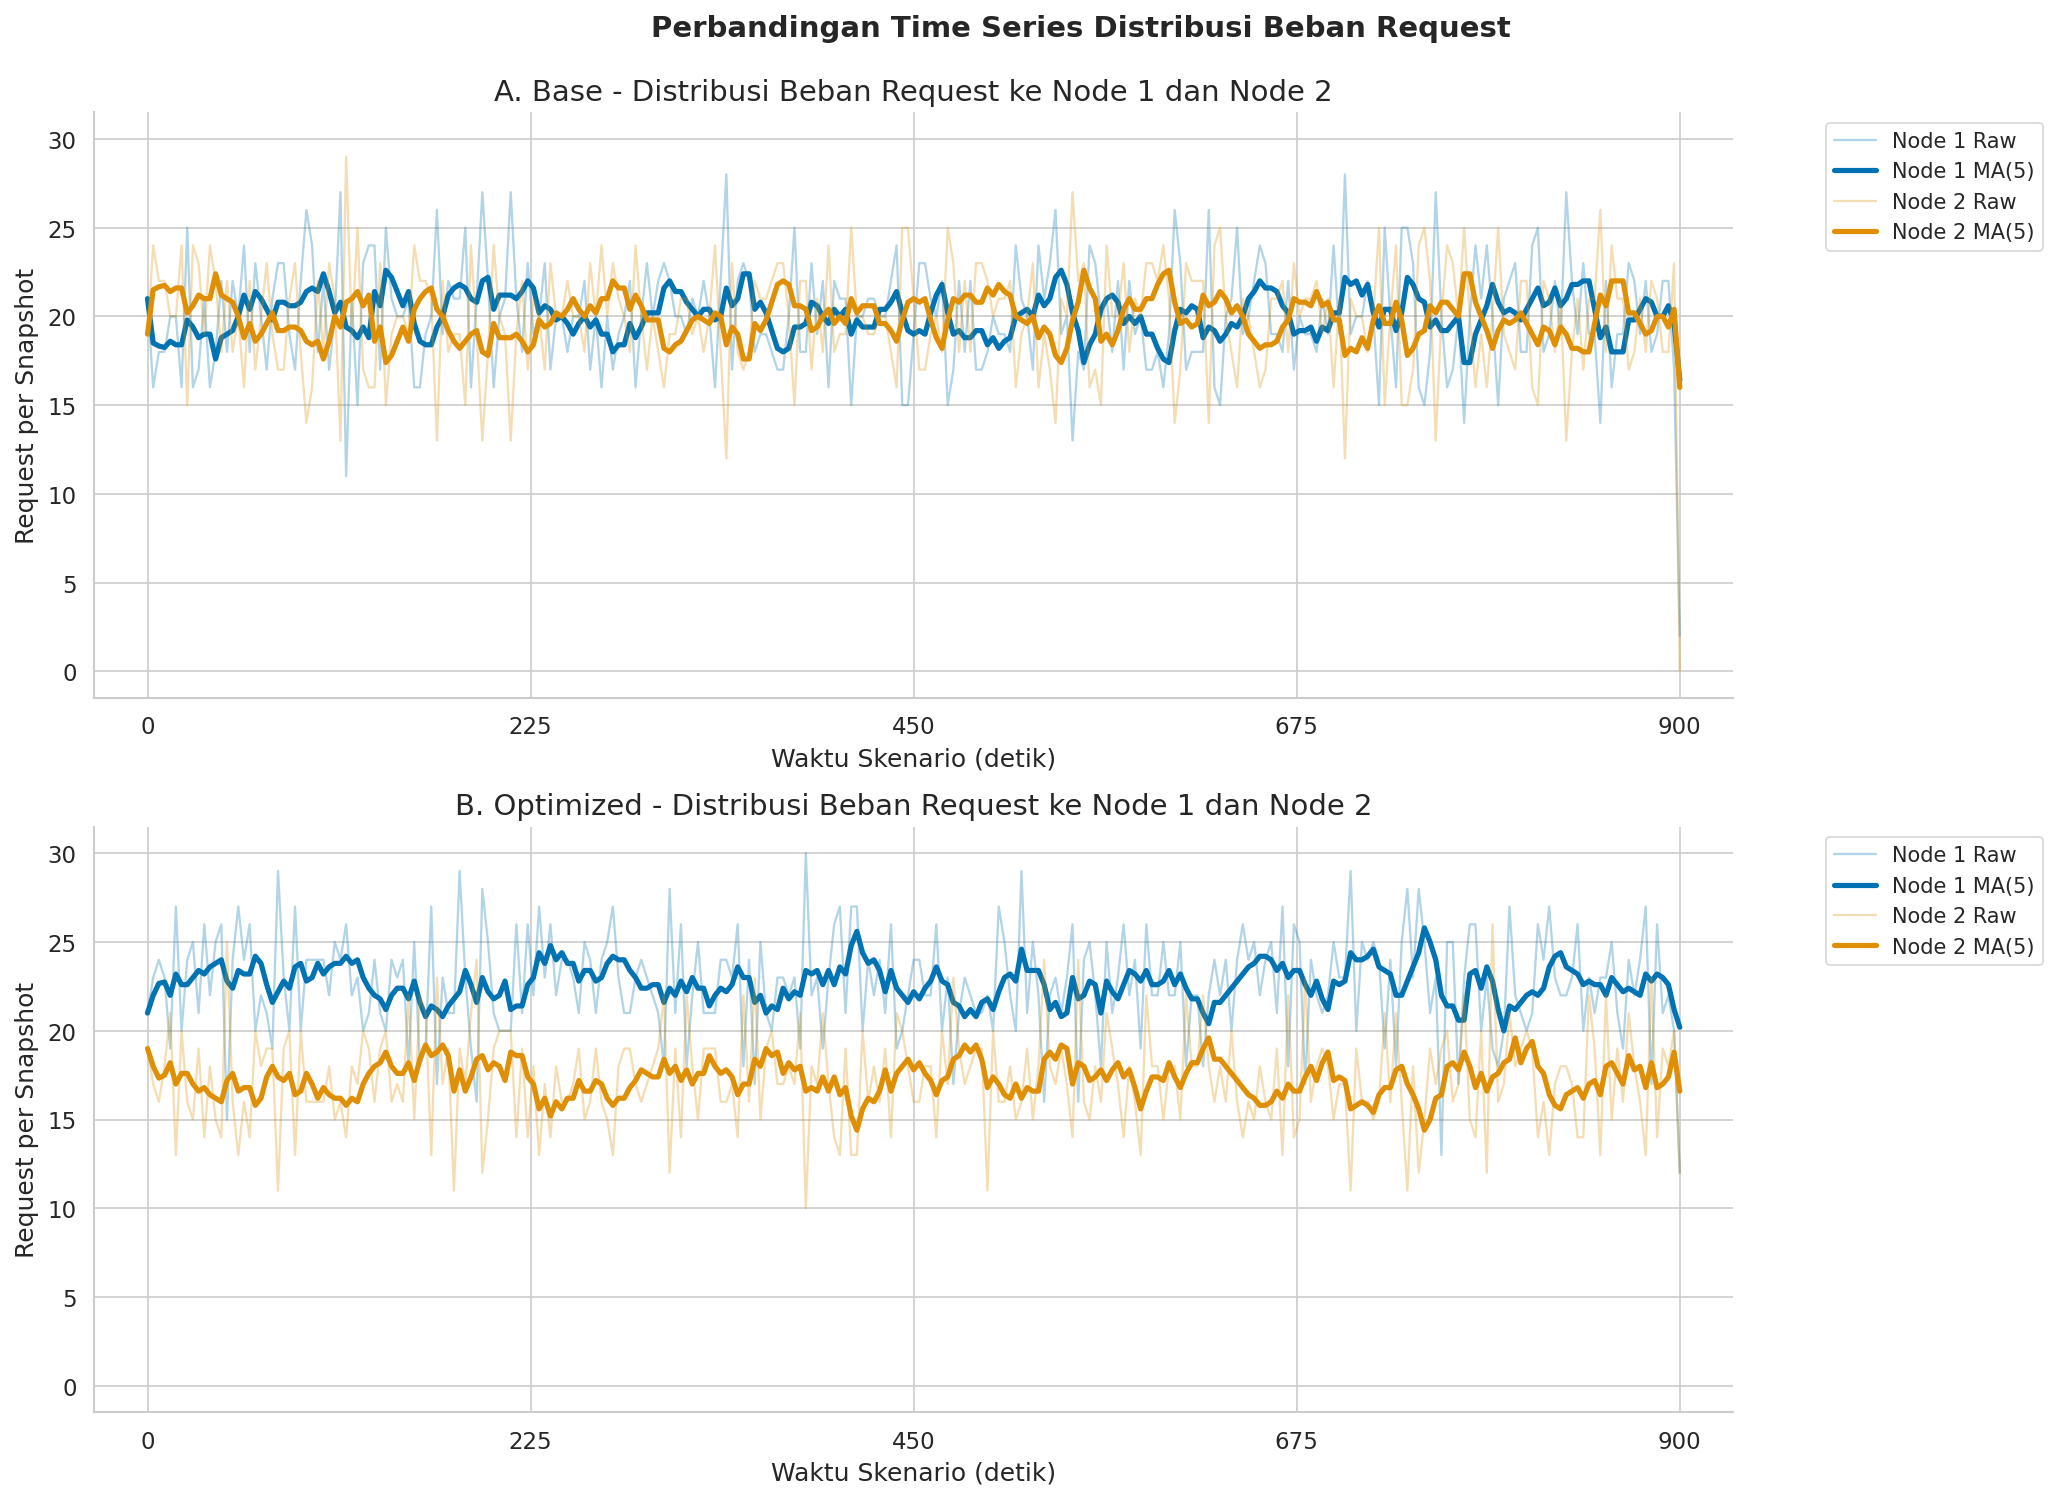

Tersimpan: /home/asus/code/loadBalancer/project-fpso/tests/colab/output_spike/normal_request_load_distribution_timeseries.png


,Dataset,Request Node 1,Request Node 2,Total Request,Share Node 1 (%),Share Node 2 (%),Gap Distribusi (%),Gap Maks Snapshot (request),Waktu Gap Maks (detik)
0,Base,5428.0,5374.0,10802.0,50.25,49.75,0.50,18.0,116.67
1,Optimized,6138.0,4682.0,10820.0,56.73,43.27,13.46,20.0,386.67


In [38]:
fig, axes = plt.subplots(2, 1, figsize=(14.5, 10), sharex=True, sharey=True)

plot_request_distribution_panel(
    axes[0],
    base_df,
    "A. Base - Distribusi Beban Request ke Node 1 dan Node 2",
    MOVING_AVG_WINDOW,
    COMMON_TIME_LIMIT_SECONDS,
    TIME_AXIS_LABEL,
)
plot_request_distribution_panel(
    axes[1],
    optimized_df,
    "B. Optimized - Distribusi Beban Request ke Node 1 dan Node 2",
    MOVING_AVG_WINDOW,
    COMMON_TIME_LIMIT_SECONDS,
    TIME_AXIS_LABEL,
)

for ax in axes:
    place_legend_outside(ax)

fig.suptitle("Perbandingan Time Series Distribusi Beban Request", y=0.995, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.85, 1])

load_distribution_plot_path = OUTPUT_DIR / "{}_request_load_distribution_timeseries.png".format(RUN_LABEL)
save_and_show(fig, load_distribution_plot_path)

display(load_metrics_df.round(2))


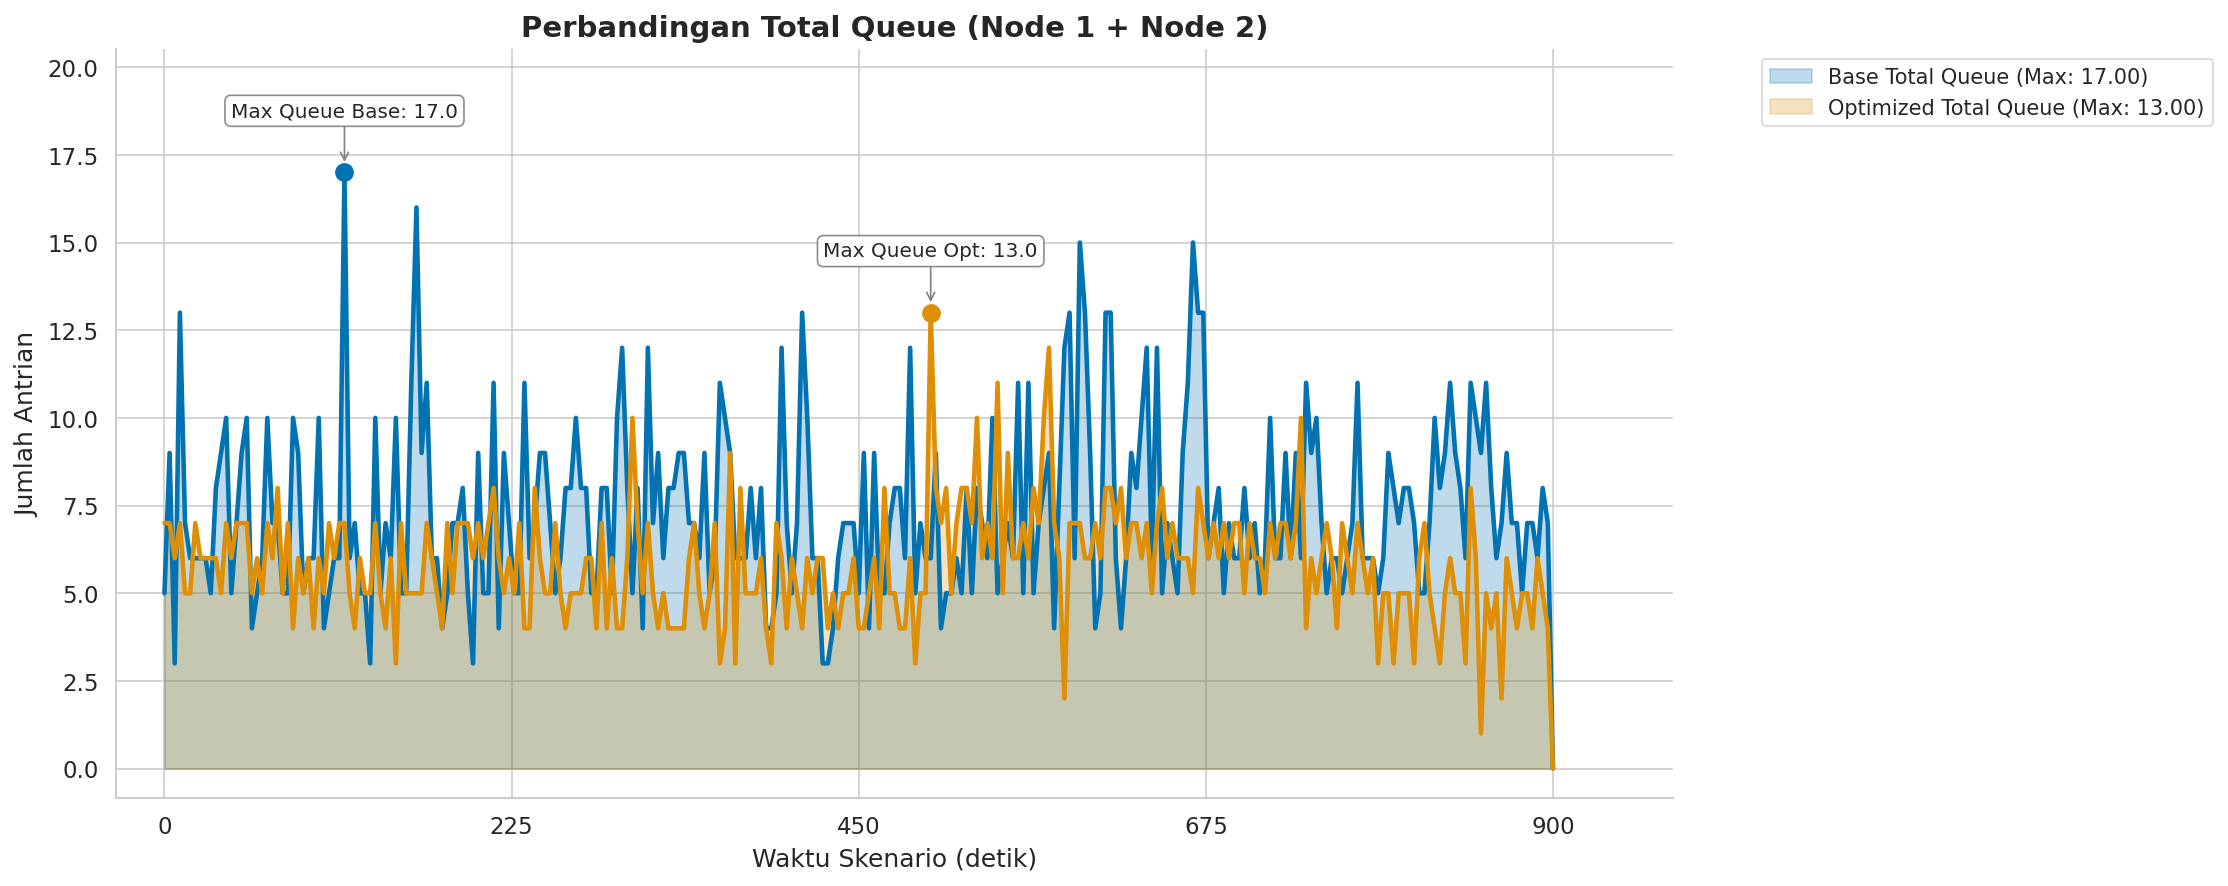

Tersimpan: /home/asus/code/loadBalancer/project-fpso/tests/colab/output_spike/normal_queue_comparison.png


,Dataset,Rata-rata Queue,P95 Queue,Puncak Queue,Waktu Puncak Queue (detik)
0,Base,7.33,12.0,17.0,116.67
1,Optimized,5.79,8.0,13.0,496.67


In [39]:
fig, ax = plt.subplots(figsize=(14, 6))

base_x = base_df["plot_seconds"].to_numpy(dtype=float)
base_queue = base_df["total_queue"].to_numpy(dtype=float)
optimized_x = optimized_df["plot_seconds"].to_numpy(dtype=float)
optimized_queue = optimized_df["total_queue"].to_numpy(dtype=float)

base_queue_max = float(np.nanmax(base_queue)) if base_queue.size else np.nan
optimized_queue_max = float(np.nanmax(optimized_queue)) if optimized_queue.size else np.nan

ax.fill_between(
    base_x,
    base_queue,
    color=DATASET_PALETTE["Base"],
    alpha=0.25,
    label="Base Total Queue (Max: {:.2f})".format(base_queue_max),
)
ax.plot(base_x, base_queue, color=DATASET_PALETTE["Base"], linewidth=2.2)

ax.fill_between(
    optimized_x,
    optimized_queue,
    color=DATASET_PALETTE["Optimized"],
    alpha=0.25,
    label="Optimized Total Queue (Max: {:.2f})".format(optimized_queue_max),
)
ax.plot(optimized_x, optimized_queue, color=DATASET_PALETTE["Optimized"], linewidth=2.2)

base_peak_idx = safe_peak_index(base_queue)
optimized_peak_idx = safe_peak_index(optimized_queue)
if base_peak_idx is not None:
    annotate_peak_left(
        ax,
        float(base_x[base_peak_idx]),
        float(base_queue[base_peak_idx]),
        "Max Queue Base: {:.1f}".format(float(base_queue[base_peak_idx])),
        DATASET_PALETTE["Base"],
    )
if optimized_peak_idx is not None:
    annotate_peak_left(
        ax,
        float(optimized_x[optimized_peak_idx]),
        float(optimized_queue[optimized_peak_idx]),
        "Max Queue Opt: {:.1f}".format(float(optimized_queue[optimized_peak_idx])),
        DATASET_PALETTE["Optimized"],
    )

ax.set_title("Perbandingan Total Queue (Node 1 + Node 2)", fontweight="bold")
format_time_axis(ax, COMMON_TIME_LIMIT_SECONDS, TIME_AXIS_LABEL)
ax.set_ylabel("Jumlah Antrian")
apply_axis_layout_padding(ax, apply_y_headroom=True)
place_legend_outside(ax)

plt.tight_layout(rect=[0, 0, 0.85, 1])

queue_plot_path = OUTPUT_DIR / "{}_queue_comparison.png".format(RUN_LABEL)
save_and_show(fig, queue_plot_path)

display(queue_metrics_df.round(2))


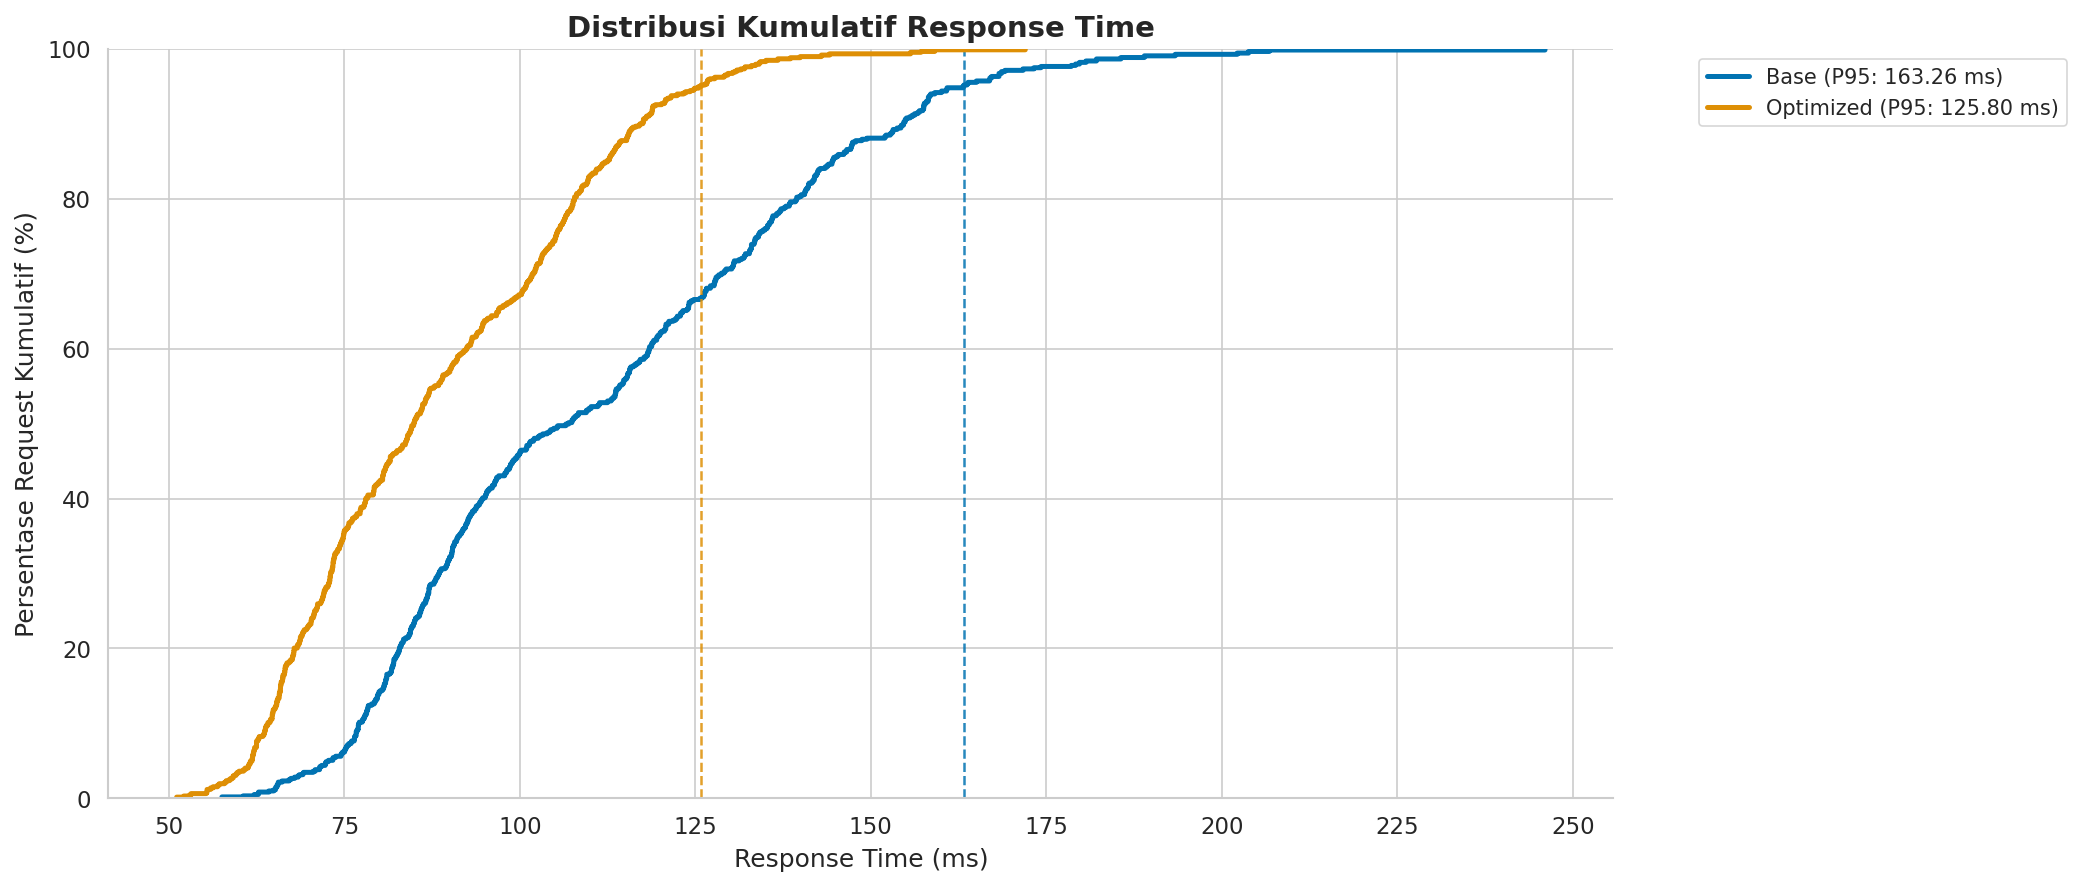

Tersimpan: /home/asus/code/loadBalancer/project-fpso/tests/colab/output_spike/normal_response_time_cumulative_distribution.png


,Dataset,Mean RT (ms),P50 RT (ms),P95 RT (ms),P99 RT (ms),RT Tertinggi (ms)
0,Base,111.43,106.96,163.26,188.96,246.03
1,Optimized,88.51,84.92,125.80,142.95,172.00


In [40]:
fig, ax = plt.subplots(figsize=(13.5, 6))

for dataset_label in ["Base", "Optimized"]:
    metrics = rt_metrics_df.loc[rt_metrics_df["Dataset"] == dataset_label].iloc[0]
    x_values, cumulative = build_weighted_ecdf(rt_distribution_df, dataset_label)
    color = DATASET_PALETTE[dataset_label]

    ax.step(
        x_values,
        cumulative * 100.0,
        where="post",
        linewidth=2.4,
        label="{} (P95: {:.2f} ms)".format(dataset_label, metrics["P95 RT (ms)"]),
        color=color,
    )
    ax.axvline(metrics["P95 RT (ms)"], color=color, linestyle="--", linewidth=1.2, alpha=0.85)

ax.set_title("Distribusi Kumulatif Response Time", fontweight="bold")
ax.set_xlabel("Response Time (ms)")
ax.set_ylabel("Persentase Request Kumulatif (%)")
ax.set_ylim(0, 100)
ax.margins(x=0.05)
place_legend_outside(ax)

plt.tight_layout(rect=[0, 0, 0.85, 1])

rt_distribution_plot_path = OUTPUT_DIR / "{}_response_time_cumulative_distribution.png".format(RUN_LABEL)
save_and_show(fig, rt_distribution_plot_path)

display(
    rt_metrics_df[[
        "Dataset",
        "Mean RT (ms)",
        "P50 RT (ms)",
        "P95 RT (ms)",
        "P99 RT (ms)",
        "RT Tertinggi (ms)",
    ]].round(2)
)
